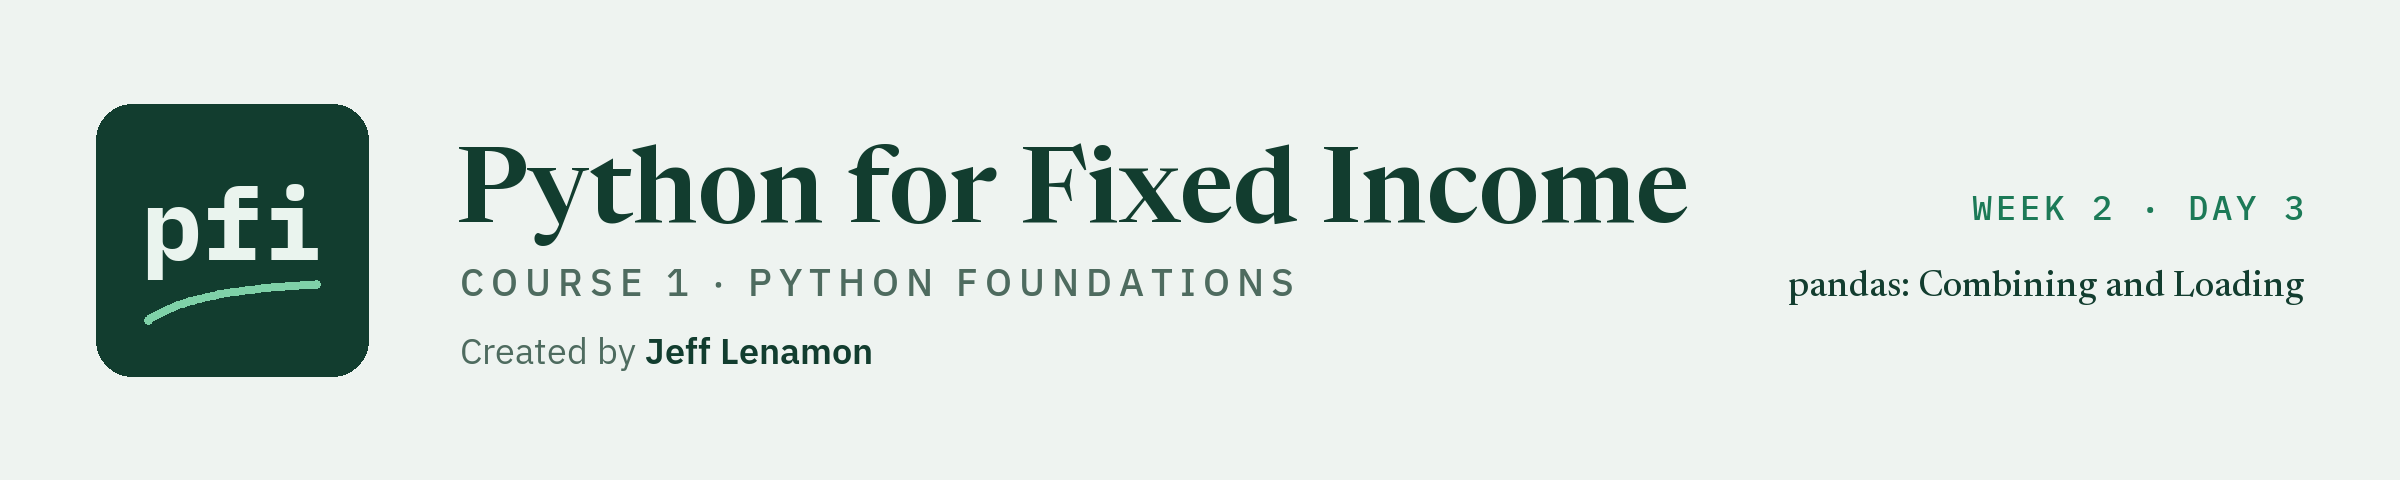

# pandas: Combining and Loading

Week 2. Joining the desk's tables together, summarizing by group, saving results to a file, and working with dates.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/week2/day3/08_pandas_combining_and_loading.ipynb)

Yesterday the desk worked with one table, and everything it needed was already in it. That is not how data usually arrives. The positions come from one system, the issuer details from another, and the rating scale from a third. The benchmark is a file of its own.

Today is about putting tables together and getting answers out of the result: joining two tables on a shared column, stacking tables on top of each other, summarizing by sector and rating, saving a result to a file and reading it back, and turning a column of date text into real dates.

These are the files, all in the `data` folder of the course repo. The issuers are invented.

| File | Rows | What it holds |
| --- | --- | --- |
| `positions.csv` | 200 bonds | what the desk holds: CUSIP, ticker, coupon, maturity, price, face held |
| `issuers.csv` | 150 issuers | issuer name, sector, country, and rating for each ticker |
| `ratings.csv` | 18 ratings | a numeric score, a rating bucket, and a grade for each rating |
| `holdings.csv` | 200 bonds | yesterday's file: the same 200 bonds with every column filled in |
| `benchmark.csv` | 821 bonds | the benchmark the portfolio is measured against |

## 8.1 The Desk's Files

Q. Import pandas and load the positions file. How large is it, and what do the first rows look like?

In [1]:
import os

import pandas as pd

# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../data/holdings.csv'):
    data_folder = '../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# the file name is added to the folder to make the full location
positions = pd.read_csv(data_folder + 'positions.csv')
print(positions.shape)
positions.head(3)

(200, 6)


,cusip,ticker,coupon,maturity,price,par_held
0,99080CAE8,BEZE,7.000,2032-06-18,106.727,5000000
1,99049XAE2,BEZH,8.125,2029-04-17,97.556,250000
2,99039NAC0,BEZL,5.125,2030-06-03,98.730,1500000


* (200, 6): 200 bonds and six columns. This is the lean file a position system sends: what the bond is, where it is priced, and how much the desk holds.
* `data_folder` holds the location of the folder, chosen once by the `if`. Each file is then read as `data_folder + 'file name'`. Joining two pieces of text with `+` is from week 1.
* The file has a ticker and nothing else about the issuer: no name, no sector, no rating.

Q. Load the issuer file. Does any ticker appear in it more than once?

In [2]:
issuers = pd.read_csv(data_folder + 'issuers.csv')
print(issuers.shape)

# nunique() is the number of distinct values, from the last notebook
print('Distinct tickers:', issuers['ticker'].nunique())
issuers.head(3)

(150, 5)
Distinct tickers: 150


,ticker,issuer,sector,country,rating
0,QVNE,Quorvane Energy,Energy,US,BBB
1,DNMR,Dunmarrow Rail,Transportation,US,BB+
2,PLWK,Pellwick Paper,Materials,US,A-


* 150 rows and 150 distinct tickers, so each issuer is listed once. A table that is used for lookups must have each key once. Section 8.3 shows what happens when it does not.
* The first three issuers are the first three tickers of week 1: QVNE, DNMR, and PLWK.

Q. Load the rating scale and show its first eleven rows.

In [3]:
ratings = pd.read_csv(data_folder + 'ratings.csv')
print(ratings.shape)
ratings.head(11)

(18, 4)


,rating,score,bucket,grade
0,AAA,1,AAA,Investment Grade
1,AA+,2,AA,Investment Grade
2,AA,3,AA,Investment Grade
3,AA-,4,AA,Investment Grade
4,A+,5,A,Investment Grade
5,A,6,A,Investment Grade
6,A-,7,A,Investment Grade
7,BBB+,8,BBB,Investment Grade
8,BBB,9,BBB,Investment Grade
9,BBB-,10,BBB,Investment Grade


* Eighteen ratings, one row each. `score` is the number we gave each rating in week 1: 1 for AAA, counting up as the rating goes down.
* `bucket` groups the notches: AA+, AA, and AA- are all in the AA bucket.
* `grade` is Investment Grade down to BBB-, score 10, and High Yield from BB+, score 11, in the last row shown.

Q. How many different tickers does the desk hold?

In [4]:
print('Tickers in the positions file:', positions['ticker'].nunique())

Tickers in the positions file: 115


* 115 tickers across 200 bonds. The positions file has many rows per ticker, and the issuer file has one row per ticker. That is the usual shape of a lookup: many on one side, one on the other.

## 8.2 merge: A Lookup Across Tables

In Excel the next step is a `VLOOKUP` on the ticker, filled down 200 rows, once for each column wanted. In pandas it is one call to `merge`.

Q. Add the issuer name, the sector, and the rating to every position. How many rows go in, and how many come out?

In [5]:
# the columns to bring in, plus the ticker to match on
issuer_details = issuers[['ticker', 'issuer', 'sector', 'rating']]

# pd.merge() matches the rows of two tables on a shared column
named = pd.merge(positions, issuer_details, on='ticker')

print('Positions:', positions.shape)
print('Issuer details:', issuer_details.shape)
print('Merged:', named.shape)
named.head(3)

Positions: (200, 6)
Issuer details: (150, 4)
Merged: (200, 9)


,cusip,ticker,coupon,maturity,price,par_held,issuer,sector,rating
0,99080CAE8,BEZE,7.000,2032-06-18,106.727,5000000,Bezane Finance,Financials,BBB-
1,99049XAE2,BEZH,8.125,2029-04-17,97.556,250000,Bezamyth Machinery,Industrials,B
2,99039NAC0,BEZL,5.125,2030-06-03,98.730,1500000,Bezoquil Freight,Transportation,BB


* `pd.merge(left, right, on='ticker')` takes each row of the left table, finds the row of the right table with the same ticker, and puts the two side by side. `on=` names the column to match on, called the **key**. It appears once in the result.
* 200 rows went in and 200 came out, and the table grew from six columns to nine. The first position, BEZE, now carries Bezane Finance, Financials, and BBB-.
* Always print the row count after a merge. The count can change without any error: rows are dropped when a key has no match, and rows are repeated when a key is listed twice in the lookup table. Either one changes every total that follows.

The rating scale is keyed on the rating. Can the positions be joined to it directly?

In [6]:
# the positions file has no rating column
pd.merge(positions, ratings, on='rating')

KeyError: 'rating'

* A `KeyError: 'rating'`. The key has to exist in both tables under the same name, and `positions` has no `rating` column. The rating arrived with the issuer details, so the table to use is `named`.
* When a merge raises a `KeyError`, print the `columns` of both tables and compare the names.
* If the key has a different name in each table, such as `ticker` in one and `issuer_ticker` in the other, use `left_on=` and `right_on=` in place of `on=`.

Q. Add the score and the grade of each rating to the table.

In [7]:
# match each position's rating to the rating scale
rated = pd.merge(named, ratings[['rating', 'score', 'grade']], on='rating')

print('Merged:', rated.shape)
rated[['ticker', 'issuer', 'rating', 'score', 'grade']].head(3)

Merged: (200, 11)


,ticker,issuer,rating,score,grade
0,BEZE,Bezane Finance,BBB-,10,Investment Grade
1,BEZH,Bezamyth Machinery,B,15,High Yield
2,BEZL,Bezoquil Freight,BB,12,High Yield


* Still 200 rows, now with eleven columns. BEZE, rated BBB-, has a score of 10 and is Investment Grade. BEZH, rated B, has a score of 15 and is High Yield.
* Two merges in a row: positions to issuers on the ticker, then the result to the rating scale on the rating. Each one is a lookup from a different table.

Yesterday, sorting by rating gave alphabetical order, with AAA in seventh place. The score fixes that.

Q. List the ratings the desk holds, in credit order.

In [8]:
# sort by the numeric score, then list each rating once
in_credit_order = rated.sort_values('score')
print(in_credit_order['rating'].unique().tolist())

['AAA', 'AA+', 'AA', 'AA-', 'A+', 'A', 'A-', 'BBB+', 'BBB', 'BBB-', 'BB+', 'BB', 'BB-', 'B+', 'B', 'B-', 'CCC+', 'CCC']


* AAA first, then AA+, AA, AA-, and so on down to CCC. A number sorts the way a rating should. Text does not.

Q. How many positions are investment grade, and how many are high yield?

In [9]:
rated['grade'].value_counts()

grade
Investment Grade    128
High Yield           72
Name: count, dtype: int64

* 128 investment grade positions and 72 high yield. Yesterday's file could not answer this, because the grade is not in it. The answer came from joining three tables.

**Excel side by side.**

| Step | pandas | Excel |
| --- | --- | --- |
| Bring in one column | `pd.merge(positions, issuers[['ticker', 'sector']], on='ticker')` | `=VLOOKUP(B2, issuers!A:C, 3, FALSE)` filled down |
| The same, without counting columns | the same line | `=XLOOKUP(B2, issuers!A:A, issuers!C:C)` or `INDEX` and `MATCH` |
| Bring in three columns | one `merge` with three columns in the list | three formulas, each filled down |
| A key with no match | the row is dropped, or kept with a blank: see section 8.3 | `#N/A` |

The Excel formulas assume the ticker in column B of the positions sheet, and an `issuers` sheet with the ticker in column A and the sector in column C. `merge` brings in every column in one step and names the key. `VLOOKUP` brings in one column at a time and counts to it.

## 8.3 Inner, Left, Right, and Outer

In the last section every ticker found a match. When some keys have no match, the `how=` argument decides which rows are kept. The difference is easiest to see on two small tables made by hand.

Q. Make a table of the four week 1 positions, and a sector table that is missing one of them and has one extra ticker.

In [10]:
# the desk's four bonds
desk_small = pd.DataFrame({
    'ticker': ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    'face': [1500000, 500000, 750000, 250000],
})

# a sector table with no row for HLVF, and a row for THAR, which the desk does not hold
sector_small = pd.DataFrame({
    'ticker': ['QVNE', 'DNMR', 'PLWK', 'THAR'],
    'sector': ['Energy', 'Transportation', 'Materials', 'Materials'],
})

print(desk_small)
print()
print(sector_small)

  ticker     face
0   QVNE  1500000
1   DNMR   500000
2   PLWK   750000
3   HLVF   250000

  ticker          sector
0   QVNE          Energy
1   DNMR  Transportation
2   PLWK       Materials
3   THAR       Materials


* Three tickers are in both tables. HLVF is only in the desk's table, and THAR is only in the sector table.

Q. Merge the two tables without saying how.

In [11]:
# how='inner' is the default: keep only the keys found in both tables
pd.merge(desk_small, sector_small, on='ticker', how='inner')

,ticker,face,sector
0,QVNE,1500000,Energy
1,DNMR,500000,Transportation
2,PLWK,750000,Materials


* Three rows. HLVF and THAR are both gone, with no warning. An **inner** merge keeps a row only when its key is in both tables.
* This is the quiet way to lose a position: 250,000 of face disappeared from the table, and nothing said so.

Q. Keep every row of the desk's table, matched or not.

In [12]:
# how='left' keeps every row of the left table
left_join = pd.merge(desk_small, sector_small, on='ticker', how='left')
left_join

,ticker,face,sector
0,QVNE,1500000,Energy
1,DNMR,500000,Transportation
2,PLWK,750000,Materials
3,HLVF,250000,NaN


* Four rows. HLVF is kept, and its sector shows as `NaN`, which stands for 'not a number' and is how pandas marks a missing value. THAR is not in the result, because it is not in the left table.
* A **left** merge is the closest match to a `VLOOKUP`: every row of your table stays, and a failed lookup leaves a gap in place of `#N/A`. For adding details to a list of positions it is the safe choice.

Q. Which of the desk's bonds found no sector?

In [13]:
# isna() is True where a value is missing
no_sector = left_join['sector'].isna()
print('Rows with no match:', no_sector.sum())
left_join[no_sector]

Rows with no match: 1


,ticker,face,sector
3,HLVF,250000,NaN


* One row, HLVF. `isna()` returns a mask, so it filters and counts like any condition from the last notebook. `notna()` is its opposite.

Q. Now keep every row of the sector table.

In [14]:
# how='right' keeps every row of the right table
pd.merge(desk_small, sector_small, on='ticker', how='right')

,ticker,face,sector
0,QVNE,1500000.0,Energy
1,DNMR,500000.0,Transportation
2,PLWK,750000.0,Materials
3,THAR,NaN,Materials


* Four rows again, but a different four. THAR is kept with a missing face amount, and HLVF is gone.
* The face column now shows a decimal point: 1500000.0. A whole-number column cannot hold `NaN`, so pandas changed the column to `float64` to make room for the gap.

Q. Keep every row of both tables, and show where each row came from.

In [15]:
# how='outer' keeps every key from either table. indicator=True adds a column that says where each row was found.
pd.merge(desk_small, sector_small, on='ticker', how='outer', indicator=True)

,ticker,face,sector,_merge
0,DNMR,500000.0,Transportation,both
1,HLVF,250000.0,NaN,left_only
2,PLWK,750000.0,Materials,both
3,QVNE,1500000.0,Energy,both
4,THAR,NaN,Materials,right_only


* Five rows: the three matches, HLVF, and THAR. The rows come out sorted by ticker.
* The `_merge` column reads `both` for a match, `left_only` for a key found only in the left table, and `right_only` for a key found only in the right table. It is the quickest way to see what did not match.

| `how=` | Rows kept | Rows here |
| --- | --- | --- |
| `'inner'` (the default) | keys found in both tables | 3 |
| `'left'` | every row of the left table | 4 |
| `'right'` | every row of the right table | 4 |
| `'outer'` | every key from either table | 5 |

A merge can also add rows. Suppose the sector table lists one ticker twice.

Q. Merge the desk's table with a sector table that has two rows for QVNE. What happens to the total face?

In [16]:
# QVNE appears twice in this lookup table
sector_twice = pd.DataFrame({
    'ticker': ['QVNE', 'QVNE', 'DNMR', 'PLWK', 'HLVF'],
    'sector': ['Energy', 'Energy', 'Transportation', 'Materials', 'Consumer'],
})

doubled = pd.merge(desk_small, sector_twice, on='ticker', how='left')
print(doubled)
print()
print('Face before the merge:', desk_small['face'].sum())
print('Face after the merge:', doubled['face'].sum())

  ticker     face          sector
0   QVNE  1500000          Energy
1   QVNE  1500000          Energy
2   DNMR   500000  Transportation
3   PLWK   750000       Materials
4   HLVF   250000        Consumer

Face before the merge: 3000000
Face after the merge: 4500000


* Five rows from a four-row table. The QVNE position matched both QVNE rows of the lookup table, so it appears twice, and the total face went from 3,000,000 to 4,500,000.
* There was no error. The only sign is the row count, which is why it is checked after every merge. The cure is a lookup table with each key once, which `nunique()` confirmed for the issuer file in section 8.1.

Q. Back to the real files. Did every one of the 200 positions find its issuer?

In [17]:
# a left merge keeps all 200 positions, and the indicator shows which ones matched
matched = pd.merge(positions, issuer_details, on='ticker', how='left', indicator=True)

print('Rows:', matched.shape[0])
matched['_merge'].value_counts()

Rows: 200


_merge
both          200
left_only       0
right_only      0
Name: count, dtype: int64

* 200 rows, and all 200 read `both`. No position is missing an issuer, so the inner merge in section 8.2 dropped nothing.

**Excel side by side.** A left merge is `VLOOKUP` filled down: every row of the sheet stays and a failed lookup shows `#N/A`. Finding the failures is `=ISNA(...)` in Excel and `isna()` in pandas. Excel has no single step for an inner or an outer merge. Those take a lookup followed by a filter, or Power Query.

## 8.4 The Portfolio Against the Benchmark

The same tool answers a question every desk asks: which bonds of the benchmark does the portfolio hold? Both files identify a bond by its CUSIP, so the CUSIP is the key.

Q. Load the full holdings file and the benchmark file. How large is each?

In [18]:
holdings = pd.read_csv(data_folder + 'holdings.csv')
benchmark = pd.read_csv(data_folder + 'benchmark.csv')

print('Holdings:', holdings.shape)
print('Benchmark:', benchmark.shape)
print('Sum of the benchmark weights:', round(benchmark['weight_pct'].sum(), 2))

Holdings: (200, 19)
Benchmark: (821, 19)
Sum of the benchmark weights: 100.0


* The holdings file has 200 bonds and the benchmark has 821. Both have 19 columns. Where the holdings have `par_held`, the benchmark has `weight_pct`: the weight of each bond in the benchmark, in percent.
* The weights add up to 100.

Q. Mark each benchmark bond with the face the desk holds in it.

In [19]:
# the benchmark is the left table, so all 821 of its bonds are kept
desk_face = holdings[['cusip', 'par_held']]
compared = pd.merge(benchmark, desk_face, on='cusip', how='left')

print('Rows:', compared.shape[0])
compared[['cusip', 'ticker', 'sector', 'weight_pct', 'par_held']].head(4)

Rows: 821


,cusip,ticker,sector,weight_pct,par_held
0,99001BAA4,QVNE,Energy,0.2076,2750000.0
1,99001BAB2,QVNE,Energy,0.1551,NaN
2,99001BAC0,QVNE,Energy,0.0245,NaN
3,99001BAD8,QVNE,Energy,0.2024,NaN


* 821 rows, one per benchmark bond. `par_held` is filled in where the desk holds the bond and is `NaN` where it does not. Of the four QVNE bonds shown, the desk holds the first, with 2,750,000 of face.
* We passed two columns of the holdings: the key and the one column wanted. If both tables bring a column with the same name, such as `price`, pandas keeps both and renames them `price_x` and `price_y`.

Q. How many benchmark bonds does the portfolio hold, and what share of the benchmark's weight are they?

In [20]:
# a missing face amount means the desk does not hold the bond
not_held = compared['par_held'].isna()
held = compared['par_held'].notna()

print('Held:', held.sum())
print('Not held:', not_held.sum())
print('Benchmark weight of the bonds held:', round(compared.loc[held, 'weight_pct'].sum(), 2))
print('Benchmark weight of the bonds not held:', round(compared.loc[not_held, 'weight_pct'].sum(), 2))

Held: 200
Not held: 621
Benchmark weight of the bonds held: 24.56
Benchmark weight of the bonds not held: 75.44


* The portfolio holds 200 of the benchmark's 821 bonds and does not hold the other 621.
* The 200 bonds held make up 24.56 percent of the benchmark by weight. The 621 not held make up 75.44 percent.

Q. Does the portfolio hold anything that is not in the benchmark?

In [21]:
# an outer merge keeps every CUSIP from either file
both_files = pd.merge(benchmark, desk_face, on='cusip', how='outer', indicator=True)
both_files['_merge'].value_counts()

_merge
left_only     621
both          200
right_only      0
Name: count, dtype: int64

* 621 bonds are `left_only`, in the benchmark alone. 200 are in both files. None is `right_only`, so every bond the desk holds is a benchmark bond.
* These are counts and weights and nothing more. They describe where the two files overlap.

**Excel side by side.** In Excel this is a helper column on the benchmark sheet: `=COUNTIF(holdings!B:B, B2)` gives 1 for a bond the desk holds and 0 for one it does not, and `=SUMIF(T:T, 1, S:S)` adds up the weights of the bonds held, with the helper in column T and the weight in column S. The pandas version is the left merge, followed by `isna()`.

## 8.5 Stacking Tables with concat

`merge` puts tables side by side and adds columns. The other way to combine tables is to stack them and add rows. First, a table worth stacking.

Q. Add the score, the bucket, and the grade to the full holdings file. Call the result `book`.

In [22]:
# holdings.csv already has the rating of each bond, so one merge is enough
book = pd.merge(holdings, ratings, on='rating')
print(book.shape)

(200, 22)


* (200, 22): the 19 columns of the holdings plus `score`, `bucket`, and `grade`. `book` is the table for the rest of the lesson.

Suppose the investment grade and the high yield positions are kept by two different traders and arrive as two tables.

Q. Split the book into its investment grade and high yield rows, then put the two parts back together.

In [23]:
# the two parts, as they might arrive from two traders
ig_book = book[book['grade'] == 'Investment Grade']
hy_book = book[book['grade'] == 'High Yield']
print('Investment grade:', ig_book.shape)
print('High yield:', hy_book.shape)

# pd.concat() stacks a list of tables on top of each other
stacked = pd.concat([ig_book, hy_book])
print('Stacked:', stacked.shape)
print('Market value:', stacked['market_value'].sum())

Investment grade: (128, 22)
High yield: (72, 22)
Stacked: (200, 22)
Market value: 490819215.0


* 128 rows and 72 rows stack into 200. The columns are the same 22, and the market value is 490,819,215, the total from the last notebook. Nothing was lost or repeated.
* `pd.concat()` takes a list of tables, in square brackets, and lines the columns up by name. A column that is missing from one of the tables is filled with `NaN` for that table's rows.

Q. What are the row labels where the first table ends and the second begins?

In [24]:
# rows 126 to 129 of the stacked table: the last two investment grade rows and the first two high yield rows
print(stacked.index[126:130].tolist())

# ignore_index=True throws the old labels away and numbers the rows again from 0
stacked = pd.concat([ig_book, hy_book], ignore_index=True)
print(stacked.index[126:130].tolist())

[198, 199, 1, 2]
[126, 127, 128, 129]


* Without `ignore_index`, each row keeps the label it had in `book`: 198 and 199 at the end of the investment grade rows, then 1 and 2 at the start of the high yield rows.
* With `ignore_index=True` the labels are 126, 127, 128, 129: one clean run from 0 to 199.
* It matters most when the tables each count from 0, such as two daily files. Stacked as they are, the labels 0, 1, 2 would each appear twice, and `loc[0]` would return two rows.

**Excel side by side.** `concat` is copying one sheet and pasting it under another, or `=VSTACK(range1, range2)` in current versions of Excel. Excel pastes by position, so the columns must be in the same order. pandas matches the columns by name.

## 8.6 Summarizing by Group

A list of 200 bonds is not a report. The desk wants totals and averages by sector, by rating, by grade. In Excel that is a pivot table. In pandas it is `groupby`.

Q. What is the market value of the portfolio in each sector?

In [25]:
# groupby() splits the rows into one group per sector, then sum() adds up the chosen column in each group
sector_value = book.groupby('sector')['market_value'].sum()
sector_value

sector
Consumer          56629597.5
Energy            38830005.0
Financials        68219672.5
Health Care       38908187.5
Industrials       52540745.0
Materials         71701617.5
Technology        30311760.0
Telecom           55848270.0
Transportation    48822897.5
Utilities         29006462.5
Name: market_value, dtype: float64

* Ten sectors, one total each, in alphabetical order. Energy is 38,830,005, the figure we found yesterday with a filter. `groupby` does that filter for every sector at once.
* Read the line in three parts: `groupby('sector')` says how to split the rows, `['market_value']` picks the column, and `sum()` is the calculation. Any of the statistics from the last notebook can take the place of `sum()`.
* The result is a Series, and its index is the sector.

Q. Which three sectors hold the most market value?

In [26]:
# a grouped result is a Series, so it sorts like one
top_three = sector_value.sort_values(ascending=False).head(3)
print(top_three)

# the index of the result holds the sector names
print(top_three.index.tolist())

sector
Materials     71701617.5
Financials    68219672.5
Consumer      56629597.5
Name: market_value, dtype: float64
['Materials', 'Financials', 'Consumer']


* Materials at 71,701,617.5, Financials at 68,219,672.5, and Consumer at 56,629,597.5. Those are the three sectors with 26 bonds each.
* `index.tolist()` gives the group names as a plain list.

Q. What is the average OAS in each rating bucket?

In [27]:
bucket_oas = book.groupby('bucket')['oas'].mean()

# loc with a list of labels puts the buckets in credit order
credit_order = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']
bucket_oas.loc[credit_order].round(2)

bucket
AAA     21.00
AA      37.62
A       79.41
BBB    127.82
BB     226.22
B      503.33
CCC    858.00
Name: oas, dtype: float64

* The average OAS is 21 basis points for AAA, 37.62 for AA, 79.41 for A, 127.82 for BBB, 226.22 for BB, 503.33 for B, and 858 for CCC. Each step down in rating bucket has a higher average spread than the one before.
* The A figure, 79.41, is the single-A average from the last notebook, which took an `isin()` with three ratings. With the bucket column it is one group among seven.
* `groupby` sorts the groups alphabetically. The `loc` line puts them in the order the desk reads them.

Q. For investment grade and for high yield, show the number of bonds and the mean, median, lowest, and highest OAS.

In [28]:
# agg() takes a list of statistics and returns one column for each
book.groupby('grade')['oas'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
grade,,,,,
High Yield,72,339.375000,250.5,125,1551
Investment Grade,128,99.335938,95.0,19,204


* The 128 investment grade bonds have a mean OAS of about 99.34 basis points and a median of 95, and run from 19 to 204.
* The 72 high yield bonds have a mean of 339.375 and a median of 250.5, and run from 125 to 1,551. The mean is well above the median, so a few very wide bonds are pulling it up.
* The result of `agg()` with a list is a DataFrame: one row per group, one column per statistic.

Q. Build a sector summary: the number of bonds, the market value, the average OAS, and the average duration.

In [29]:
# each line reads: new column name = (column to use, statistic)
sector_summary = book.groupby('sector').agg(
    bonds=('cusip', 'count'),
    market_value=('market_value', 'sum'),
    avg_oas=('oas', 'mean'),
    avg_duration=('duration', 'mean'),
)
sector_summary = sector_summary.round(2)
sector_summary

,bonds,market_value,avg_oas,avg_duration
sector,,,,
Consumer,26,56629597.5,218.88,6.84
Energy,17,38830005.0,171.59,6.97
Financials,26,68219672.5,172.31,6.15
Health Care,20,38908187.5,141.75,5.87
Industrials,20,52540745.0,220.55,6.33
Materials,26,71701617.5,182.42,5.61
Technology,12,30311760.0,298.17,5.75
Telecom,21,55848270.0,182.38,6.35
Transportation,20,48822897.5,126.50,8.19


* One row per sector and four columns, each from a different column of the book with its own statistic. This is the table a pivot table would give.
* Technology has the highest average OAS, 298.17 basis points, on 12 bonds. Transportation has the lowest, 126.5, and the longest average duration, 8.19 years.
* These averages count every bond equally, whatever its size. The next section deals with that.

**Excel side by side.**

| Question | pandas | Excel |
| --- | --- | --- |
| Market value of one sector | `sector_value.loc['Energy']` | `=SUMIF(E:E, "Energy", S:S)` |
| Average OAS of one sector | `book.groupby('sector')['oas'].mean().loc['Energy']` | `=AVERAGEIF(E:E, "Energy", M:M)` |
| Bonds in one sector | `book.groupby('sector')['cusip'].count().loc['Energy']` | `=COUNTIF(E:E, "Energy")` |
| Every sector at once | `book.groupby('sector')['market_value'].sum()` | a pivot table: sector in Rows, Sum of market_value in Values |
| Several statistics at once | `agg(...)` | more fields dragged into Values |

The columns are as in `holdings.csv`: sector in E, OAS in M, market value in S.

## 8.7 Weighted Averages

The average OAS of the portfolio is 185.75 basis points. That figure treats a 250,000 position and a 5,000,000 position as equals. The number a desk reports is weighted by market value: each bond counts in proportion to its size.

Q. What is the market-value-weighted average OAS of the portfolio?

In [30]:
# step 1: each bond's OAS times its market value
oas_times_value = book['oas'] * book['market_value']

# step 2: add those up, and divide by the total market value
weighted_oas = oas_times_value.sum() / book['market_value'].sum()

print('Simple average OAS:', round(book['oas'].mean(), 2))
print('Weighted average OAS:', round(weighted_oas, 2))

Simple average OAS: 185.75
Weighted average OAS: 180.46


* 180.46 basis points weighted, against 185.75 simple.
* A weighted average is the sum of value times weight, divided by the sum of the weights. Here the value is the OAS and the weight is the market value.
* The weighted figure is lower, which says the larger positions have, on the whole, lower spreads than the smaller ones.

Q. Do the same for duration.

In [31]:
# the same two steps, with duration in place of OAS
duration_times_value = book['duration'] * book['market_value']
weighted_duration = duration_times_value.sum() / book['market_value'].sum()

print('Simple average duration:', round(book['duration'].mean(), 2))
print('Weighted average duration:', round(weighted_duration, 2))

Simple average duration: 6.47
Weighted average duration: 6.25


* 6.25 years weighted, against 6.47 simple. The portfolio's duration is the weighted figure: it reflects where the money is.

Q. What is the weighted average OAS of each sector?

In [32]:
# step 1: store OAS times market value as a column, so it can be grouped
book['oas_x_value'] = book['oas'] * book['market_value']

# step 2: add up both columns within each sector
sector_sums = book.groupby('sector')[['oas_x_value', 'market_value']].sum()

# step 3: divide one total by the other, sector by sector
weighted_by_sector = sector_sums['oas_x_value'] / sector_sums['market_value']
weighted_by_sector.round(1)

sector
Consumer          209.4
Energy            176.3
Financials        176.1
Health Care       128.0
Industrials       234.0
Materials         180.7
Technology        228.2
Telecom           166.9
Transportation    120.9
Utilities         188.8
dtype: float64

* The same sum divided by a sum, done inside each sector. A list of two column names after `groupby` adds up both columns at once, and the division then works row by row because both totals are labelled by sector.

Q. Put the simple and the weighted average side by side.

In [33]:
# two Series with the same index become the two columns of a table
oas_by_sector = pd.DataFrame({
    'simple': book.groupby('sector')['oas'].mean(),
    'weighted': weighted_by_sector,
})
oas_by_sector.round(1)

,simple,weighted
sector,,
Consumer,218.9,209.4
Energy,171.6,176.3
Financials,172.3,176.1
Health Care,141.8,128.0
Industrials,220.6,234.0
Materials,182.4,180.7
Technology,298.2,228.2
Telecom,182.4,166.9
Transportation,126.5,120.9


* In nine of the ten sectors the two figures are within 16 basis points of each other. Technology is the exception: 298.2 simple and 228.2 weighted, a gap of 70.
* The weighted figure is the lower one in six sectors and the higher one in four: Energy, Financials, Industrials, and Utilities.

Q. Why are the two Technology figures so far apart?

In [34]:
# the three Technology bonds with the highest OAS, and their size
technology = book[book['sector'] == 'Technology']
widest_three = technology.nlargest(3, 'oas')

# their share of the sector's market value, in percent
share = widest_three['market_value'].sum() / technology['market_value'].sum() * 100
print('Technology bonds:', technology.shape[0])
print('Share of sector market value in the three widest:', round(share, 1))
widest_three[['ticker', 'rating', 'oas', 'market_value']]

Technology bonds: 12
Share of sector market value in the three widest: 13.5


,ticker,rating,oas,market_value
65,FESR,CCC+,1551,2216725.0
66,FESR,CCC+,614,1133162.5
98,LORE,BB-,334,752190.0


* The three widest Technology bonds have spreads of 1,551, 614, and 334 basis points. They are 3 of the sector's 12 bonds, a quarter of the count, and 13.5 percent of its market value.
* The simple average gives those three bonds a quarter of the say. The weighted average gives them 13.5 percent, so it comes out lower. Neither figure is wrong. They answer different questions: the spread of a typical bond, and the spread of a typical dollar.

**Excel side by side.**

| Question | pandas | Excel |
| --- | --- | --- |
| Simple average OAS | `book['oas'].mean()` | `=AVERAGE(M2:M201)` |
| Weighted average OAS | `(book['oas'] * book['market_value']).sum() / book['market_value'].sum()` | `=SUMPRODUCT(M2:M201, S2:S201) / SUM(S2:S201)` |
| Weighted average OAS of one sector | the `groupby` steps above | `=SUMPRODUCT((E2:E201="Energy") * M2:M201 * S2:S201) / SUMIF(E2:E201, "Energy", S2:S201)` |

`SUMPRODUCT` divided by `SUM` is the same two steps: multiply and add up, then divide by the total weight.

## 8.8 pivot_table and apply

`groupby` splits by one column and lists the groups down the page. A pivot table with a second field across the top is `pd.pivot_table`.

Q. Show the market value by sector and grade, with totals.

In [35]:
# index= goes down the side, columns= goes across the top, values= is the column to summarize
pd.pivot_table(book, values='market_value', index='sector', columns='grade',
               aggfunc='sum', margins=True)

grade,High Yield,Investment Grade,All
sector,,,
Consumer,19016165.0,37613432.5,56629597.5
Energy,7347315.0,31482690.0,38830005.0
Financials,15335395.0,52884277.5,68219672.5
Health Care,12891097.5,26017090.0,38908187.5
Industrials,22802335.0,29738410.0,52540745.0
Materials,38747115.0,32954502.5,71701617.5
Technology,6258692.5,24053067.5,30311760.0
Telecom,27796585.0,28051685.0,55848270.0
Transportation,14371525.0,34451372.5,48822897.5


* Ten sectors down the side, the two grades across the top, and a market value in each cell. `aggfunc='sum'` is the calculation, and `margins=True` adds the row and the column named `All`.
* The grand total is 490,819,215: 320,917,365 investment grade and 169,901,850 high yield.
* Materials is the one sector with more market value in high yield, 38,747,115, than in investment grade, 32,954,502.5. In Telecom the two are almost equal, at 27,796,585 and 28,051,685.

Sometimes the desk wants a label that no file carries, worked out bond by bond with a rule. `apply` runs a function on every value of a column.

Q. Label each bond Premium, Discount, or Par from its price. How many are there of each?

In [36]:
def price_label(price):
    # the label for one clean price
    if price > 100:
        return 'Premium'
    elif price < 100:
        return 'Discount'
    else:
        return 'Par'


# apply() calls the function once for each price and collects the answers
book['price_label'] = book['price'].apply(price_label)
book['price_label'].value_counts()

price_label
Discount    113
Premium      87
Name: count, dtype: int64

* 113 bonds at a discount and 87 at a premium. No bond is priced at exactly 100, so the Par label is never used. The 113 matches yesterday's count of bonds below par.
* The function is ordinary week 1 Python: one price in, one label out. `apply` takes the name of the function, with no brackets after it, and does the looping.

Q. What is the average coupon of the premium bonds and of the discount bonds?

In [37]:
# the new label is a column like any other, so it can be grouped
book.groupby('price_label')['coupon'].mean().round(2)

price_label
Discount    5.36
Premium     6.69
Name: coupon, dtype: float64

* 5.36 percent for the discount bonds and 6.69 percent for the premium bonds. The bonds priced above par are, on average, the ones with the higher coupons.

For a rule that fits on one line, the function can be written in place with `lambda`.

Q. Label each position by size: face of 1,000,000 or more, or less than that.

In [38]:
# lambda defines a small function with no name: the input, a colon, then the result
book['size_label'] = book['par_held'].apply(lambda face: '1mm and over' if face >= 1000000 else 'Under 1mm')
book['size_label'].value_counts()

size_label
1mm and over    171
Under 1mm        29
Name: count, dtype: int64

* 171 positions of 1,000,000 or more and 29 below that.
* `lambda`, from week 1, writes a function in place. `lambda face: ...` is the same as a `def` with one argument named `face` and one `return` line. Use it for one-line rules, and a named function for anything longer.
* `apply` is for rules, not for arithmetic. For a calculation such as coupon income, multiply the columns directly, as in the last notebook: it is shorter and much faster.

**Excel side by side.**

| Step | pandas | Excel |
| --- | --- | --- |
| Sector by grade | `pd.pivot_table(book, values='market_value', index='sector', columns='grade', aggfunc='sum')` | a pivot table: sector in Rows, grade in Columns, Sum of market_value in Values |
| Totals | `margins=True` | Grand Totals, on by default |
| A label from a rule | `book['price'].apply(price_label)` | `=IF(I2>100, "Premium", IF(I2<100, "Discount", "Par"))` filled down |

## 8.9 Saving and Loading

Everything built so far is in memory and is gone when the notebook closes. To hand a table to someone, or to pick it up tomorrow, save it to a file. We read CSV files with `read_csv`. The method that writes one is `to_csv`.

Nothing here writes to the `data` folder. The files go in the folder this notebook is in, and section 8.10 ends by deleting them.

Q. Save the book to a CSV file, then read it back. Is the table that comes back the same size?

In [39]:
# to_csv() writes the table to a file in the notebook's folder
book.to_csv('desk_book_with_grades.csv')

# read it back and compare
read_back = pd.read_csv('desk_book_with_grades.csv')
print('Saved:', book.shape)
print('Read back:', read_back.shape)
read_back.iloc[0:3, 0:4]

Saved: (200, 25)
Read back: (200, 26)


,Unnamed: 0,as_of_date,cusip,ticker
0,0,2026-09-30,99080CAE8,BEZE
1,1,2026-09-30,99049XAE2,BEZH
2,2,2026-09-30,99039NAC0,BEZL


* 25 columns were saved and 26 came back. The extra one is first in the table and is named `Unnamed: 0`. It holds 0, 1, 2 and so on.
* That column is the index. `to_csv` writes the row labels as the first column of the file, with no header. When the file is read back, pandas sees a column with no name and gives the table a new index as well.

Q. Save the book again without the index.

In [40]:
# index=False leaves the row labels out of the file
book.to_csv('desk_book_with_grades.csv', index=False)

read_back = pd.read_csv('desk_book_with_grades.csv')
print('Saved:', book.shape)
print('Read back:', read_back.shape)
print('File exists:', os.path.exists('desk_book_with_grades.csv'))

Saved: (200, 25)
Read back: (200, 25)


File exists: True


* 25 columns saved and 25 read back. Saving to the same name replaced the first file.
* When the index is only row numbers, write `index=False`. The numbers carry no information, and they come back as a stray column.

Q. Save the sector summary from section 8.6, and read it back.

In [41]:
# here the index holds the sector names, so it is kept
sector_summary.to_csv('sector_summary.csv')

pd.read_csv('sector_summary.csv').head(3)

,sector,bonds,market_value,avg_oas,avg_duration
0,Consumer,26,56629597.5,218.88,6.84
1,Energy,17,38830005.0,171.59,6.97
2,Financials,26,68219672.5,172.31,6.15


* The sector comes back as the first column, with its name, followed by the four summary columns.
* A grouped table is the exception to the rule. Its index is the group name, and `index=False` would save the numbers without saying which sector each row belongs to.
* A CSV file opens in Excel with a double-click, so this is the simplest way to hand a result to a colleague who does not use Python.
* Excel workbooks work the same way, with `pd.read_excel()` and `to_excel()`, once the `openpyxl` package is installed. This course stays with CSV.

**Excel side by side.** `to_csv` is File, Save As, CSV. `read_csv` is File, Open. A CSV holds values only: no formulas, no formats, no column types. The last point matters for dates, which is the next section.

## 8.10 Dates

Every date in these files has so far been text. Text can be shown and matched, but it cannot be subtracted, and nothing can be pulled out of it.

Q. What type is the maturity column?

In [42]:
print(book['maturity'].head(3))

0    2032-06-18
1    2029-04-17
2    2030-06-03
Name: maturity, dtype: str


* The values look like dates, but the last line says `dtype: str`, or `object` in older versions of pandas. To pandas each one is ten characters.

What happens if we subtract the report date from the maturity to get the time left?

In [43]:
# pd.Timestamp() makes one real date
as_of = pd.Timestamp('2026-09-30')

# the maturity column is still text
book['maturity'] - as_of

TypeError: unsupported operand type(s) for -: 'numpy.ndarray' and 'Timestamp'

* A `TypeError`: unsupported operand type(s) for `-`. The rest of the message names the two things that could not be subtracted, and its wording differs between versions of pandas.
* The first line of the cell ran, so `as_of` is a real date. The second line failed, because text minus a date has no meaning.
* This is the week 1 error of adding a number to a string, in a new place. The fix is the same kind of fix: convert the text first.

Q. Convert the maturity column to real dates.

In [44]:
# pd.to_datetime() turns a column of date text into dates
book['maturity'] = pd.to_datetime(book['maturity'])
print(book['maturity'].head(3))

0   2032-06-18
1   2029-04-17
2   2030-06-03
Name: maturity, dtype: datetime64[us]


* The values look the same, and the type is now `datetime64[us]`. Older versions of pandas show `datetime64[ns]`. Both are dates.
* The file writes its dates as year, month, day, which `to_datetime` reads without help. For a file in another layout, such as 06/18/2032, pass the layout: `pd.to_datetime(column, format='%m/%d/%Y')`.

Q. Pull the year, the month, and the day of the week out of each maturity date.

In [45]:
# .dt gives access to the parts of a date column
book['maturity_year'] = book['maturity'].dt.year
book['maturity_month'] = book['maturity'].dt.month
book['maturity_day'] = book['maturity'].dt.day_name()

book[['ticker', 'maturity', 'maturity_year', 'maturity_month', 'maturity_day']].head(3)

,ticker,maturity,maturity_year,maturity_month,maturity_day
0,BEZE,2032-06-18,2032,6,Friday
1,BEZH,2029-04-17,2029,4,Tuesday
2,BEZL,2030-06-03,2030,6,Monday


* The first bond matures on 2032-06-18: year 2032, month 6, a Friday.
* `.dt` opens up the parts of a date column. `year` and `month` are numbers and take no brackets. `day_name()` is a method, with brackets, and returns text.
* The three results are stored as ordinary columns, so they can be filtered, counted, and grouped like any other.

Q. How many bonds mature in each of the first five years?

In [46]:
# count the bonds in each maturity year, then sort_index() puts the years in order
book['maturity_year'].value_counts().sort_index().head()

maturity_year
2027     6
2028    10
2029    18
2030    14
2031    11
Name: count, dtype: int64

* 6 bonds mature in 2027, 10 in 2028, 18 in 2029, 14 in 2030, and 11 in 2031. 
* `value_counts()` sorts by count. `sort_index()` sorts by the labels, here the years, which is the order wanted for a maturity profile.

Q. How many years does each bond have left to maturity, as of 2026-09-30? What are the shortest, the longest, and the average?

In [47]:
# a date minus a date is a length of time. .dt.days gives it as a number of days.
days_left = (book['maturity'] - as_of).dt.days

# 365.25 days to a year, to allow for leap years
book['years_to_maturity'] = days_left / 365.25

print('Shortest:', round(book['years_to_maturity'].min(), 2))
print('Longest:', round(book['years_to_maturity'].max(), 2))
print('Average:', round(book['years_to_maturity'].mean(), 2))

Shortest: 1.0
Longest: 29.9
Average: 9.85


* The shortest bond has 1.0 years left and the longest 29.9. The simple average is 9.85 years.
* The subtraction that failed on text now works. It gives the calendar days between the two dates.
* Dividing by 365.25 is an approximation that is good enough for sorting and bucketing. It is not the 30/360 day count used to price these bonds and to accrue their interest.

Q. Which bonds mature before the start of 2028?

In [48]:
# a date column compares with a date the way a number column compares with a number
early = book[book['maturity'] < pd.Timestamp('2028-01-01')]
print('Count:', early.shape[0])
early[['ticker', 'coupon', 'maturity', 'par_held']]

Count: 6


,ticker,coupon,maturity,par_held
56,FARX,5.000,2027-12-22,1500000
70,GALX,7.000,2027-10-27,4750000
112,NEVR,5.125,2027-10-24,2750000
125,PLWK,5.125,2027-10-28,1000000
165,TROE,4.375,2027-12-26,3250000
177,VYRH,7.250,2027-10-02,3000000


* Six bonds: FARX, GALX, NEVR, PLWK, TROE, and VYRH. All mature between 2027-10-02 and 2027-12-26.
* A filter on dates is written like a filter on numbers. `pd.Timestamp()` makes the date to compare with.

Q. How many bonds mature within the next three years, and what is their market value?

In [49]:
# three years on from the report date
within_three = book['maturity'] <= pd.Timestamp('2029-09-30')

print('Bonds:', within_three.sum())
print('Market value:', book.loc[within_three, 'market_value'].sum())

Bonds: 28
Market value: 75125702.5


* 28 bonds, with a market value of 75,125,702.5.

Q. Put every bond in a maturity bucket: 0 to 3 years, 3 to 7, 7 to 15, and 15 and over. How many bonds are in each?

In [50]:
# pd.cut() sorts numbers into ranges. bins= lists the edges and labels= names the ranges between them.
edges = [0, 3, 7, 15, 100]
names = ['0 to 3', '3 to 7', '7 to 15', '15 and over']
book['maturity_bucket'] = pd.cut(book['years_to_maturity'], bins=edges, labels=names)

book['maturity_bucket'].value_counts().sort_index()

maturity_bucket
0 to 3         28
3 to 7         51
7 to 15        88
15 and over    33
Name: count, dtype: int64

* 28 bonds in 0 to 3 years, 51 in 3 to 7, 88 in 7 to 15, and 33 in 15 and over. The 28 agrees with the count from the date filter.
* Five edges make four ranges. Each range includes its upper edge, so a bond with exactly 3 years left goes in `0 to 3`. The last edge, 100, is a number no maturity reaches.
* `pd.cut` does in one line what `apply` with a four-way `if` would do, and it keeps the buckets in order: `sort_index()` lists them from short to long, not alphabetically.

Q. What is the market value in each maturity bucket?

In [51]:
# observed=True lists only the buckets that have bonds in them
book.groupby('maturity_bucket', observed=True)['market_value'].agg(['count', 'sum'])

,count,sum
maturity_bucket,,
0 to 3,28,75125702.5
3 to 7,51,123242385.0
7 to 15,88,228787395.0
15 and over,33,63663732.5


* 75,125,702.5 in 0 to 3 years, 123,242,385 in 3 to 7, 228,787,395 in 7 to 15, and 63,663,732.5 in 15 and over. The 7 to 15 bucket holds the most bonds, 88, and the most market value.
* Older versions of pandas print a warning when a bucket column is grouped without `observed=`. Writing it out gives the same result in every version.

Q. Which three bonds mature first?

In [52]:
# dates sort in calendar order
by_maturity = book.sort_values('maturity')
by_maturity[['cusip', 'ticker', 'coupon', 'maturity', 'years_to_maturity']].head(3)

,cusip,ticker,coupon,maturity,years_to_maturity
177,99006GAC4,VYRH,7.250,2027-10-02,1.004791
112,99026AAD1,NEVR,5.125,2027-10-24,1.065024
70,99088KAB8,GALX,7.000,2027-10-27,1.073238


* VYRH on 2027-10-02, NEVR on 2027-10-24, and GALX on 2027-10-27, all about one year out. `ascending=False` would put the longest bond first.

The file saved in section 8.9 was written before the maturity column was converted. It would make no difference if it had been written after: a CSV stores a date as text. The conversion can be done while loading.

Q. Read the saved book back, with the maturity column as dates.

In [53]:
# parse_dates= lists the columns to convert while the file is read
reloaded = pd.read_csv('desk_book_with_grades.csv', parse_dates=['maturity'])
print(reloaded[['as_of_date', 'maturity', 'price_date']].dtypes)

as_of_date               str
maturity      datetime64[us]
price_date               str
dtype: object


* `maturity` is `datetime64[us]`, or `datetime64[ns]` in older versions. The other two date columns were not listed, so they are still text: `str` here, `object` in older versions.
* `parse_dates` saves the separate `to_datetime` line. Use it whenever you know which columns of a file are dates.

Q. Delete the two files this lesson saved.

In [54]:
# os.remove() deletes a file, from the files and folders notebook
os.remove('desk_book_with_grades.csv')
os.remove('sector_summary.csv')

print('Book file exists:', os.path.exists('desk_book_with_grades.csv'))
print('Summary file exists:', os.path.exists('sector_summary.csv'))

Book file exists: False
Summary file exists: False


* False and False: both files are gone, and the folder is as we found it. The files in `data` were only read.

**Excel side by side.**

| Step | pandas | Excel |
| --- | --- | --- |
| Text to a date | `pd.to_datetime(book['maturity'])` | `=DATEVALUE(H2)` |
| Year and month | `.dt.year`, `.dt.month` | `=YEAR(H2)`, `=MONTH(H2)` |
| Day of the week | `.dt.day_name()` | `=TEXT(H2, "dddd")` |
| Years left, by calendar days | `(book['maturity'] - as_of).dt.days / 365.25` | `=(H2 - A2) / 365.25` |
| Bonds maturing before a date | `book['maturity'] < pd.Timestamp('2028-01-01')` | `=COUNTIF(H:H, "<" & DATE(2028, 1, 1))` |
| Maturity bucket | `pd.cut(...)` | a nested `IF`, or a `VLOOKUP` with an approximate match on a table of edges |

The columns are as in `holdings.csv`: the report date in A and the maturity in H. Excel stores a date as a count of days, so one date minus another is a number of days there too.

## You Can Now

* Join a position file to an issuer file and a rating scale, the job `VLOOKUP` does, and check the row count so that no position is dropped or doubled.
* Compare a portfolio with its benchmark by CUSIP: how many benchmark bonds are held and what weight they carry.
* Summarize a portfolio by sector, rating bucket, or grade, with counts, totals, and averages, and lay two groupings out as a pivot table.
* Report a market-value-weighted OAS or duration, and say why it differs from the simple average.
* Save a result to a CSV file and read it back without a stray index column.
* Turn date text into dates, and build a maturity profile: years to maturity, maturity buckets, and market value by bucket.

The next two notebooks are case studies. They put both pandas lessons to work on the desk's linked tables: holdings, issuers, and ratings.

## Exercises

The exercises use the holdings file, the benchmark file, and the rating scale, with questions the lesson did not ask. The issuers are invented.

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports pandas, loads fresh copies of the three files as `holdings`, `ratings`, and `benchmark`, and defines `check`, a small function that marks your answers. It allows for tiny rounding differences in numbers with a decimal point.

In [55]:
import os

import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of three files. In Colab they are read from GitHub.
if os.path.exists('../../data/holdings.csv'):
    data_folder = '../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
benchmark = pd.read_csv(data_folder + 'benchmark.csv')
print(holdings.shape, ratings.shape, benchmark.shape)

(200, 19) (18, 4) (821, 19)


### Exercise 1

Q. Merge the benchmark with the rating scale. How many benchmark bonds are High Yield, and what is their total weight in the benchmark, in percent, rounded to one decimal place? Store the answers in **ex1_count** and **ex1_weight**.

In [56]:
ex1_count = ...
ex1_weight = ...

In [57]:
check('Exercise 1 count', ex1_count, 281)
check('Exercise 1 weight', ex1_weight, 34.4)

Exercise 1 count: not attempted yet
Exercise 1 weight: not attempted yet


### Exercise 2

Q. Merge the holdings with the rating scale, and total the face held in each rating bucket. How much face does the desk hold in the BBB bucket? Which three buckets have the most face, largest first? Store the answers in **ex2_bbb_face** and, as a list, in **ex2_top_buckets**.

In [58]:
ex2_bbb_face = ...
ex2_top_buckets = ...

In [59]:
check('Exercise 2 BBB face', ex2_bbb_face, 151750000)
check('Exercise 2 top buckets', ex2_top_buckets, ['BBB', 'A', 'BB'])

Exercise 2 BBB face: not attempted yet
Exercise 2 top buckets: not attempted yet


### Exercise 3

Q. Keep the High Yield bonds of the holdings. What is their market-value-weighted average OAS, and their market-value-weighted average duration? Round both to two decimal places and store them in **ex3_hy_oas** and **ex3_hy_duration**.

In [60]:
ex3_hy_oas = ...
ex3_hy_duration = ...

In [61]:
check('Exercise 3 OAS', ex3_hy_oas, 334.73)
check('Exercise 3 duration', ex3_hy_duration, 5.43)

Exercise 3 OAS: not attempted yet
Exercise 3 duration: not attempted yet


### Exercise 4

Q. Convert the maturity column of the holdings to dates. How many bonds mature in the years 2040 to 2049? What is the CUSIP of the bond with the latest maturity date? Store the answers in **ex4_count** and **ex4_last_cusip**.

In [62]:
ex4_count = ...
ex4_last_cusip = ...

In [63]:
check('Exercise 4 count', ex4_count, 17)
check('Exercise 4 last CUSIP', ex4_last_cusip, '99111HAB6')

Exercise 4 count: not attempted yet
Exercise 4 last CUSIP: not attempted yet


### Exercise 5: AI check

You ask an AI assistant for the market-value-weighted average OAS of the desk's High Yield bonds. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. What number do you expect? You worked it out yourself in Exercise 3. Then run the code. Does it agree with you?

In [64]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# bring in the grade and keep the high yield bonds
book = pd.merge(holdings, ratings, on='rating')
hy = book[book['grade'] == 'High Yield']

# weighted average OAS of the high yield bonds
ex5_hy_oas = round(hy['oas'].mean(), 2)

print('Weighted average OAS of the High Yield bonds:', ex5_hy_oas)

Weighted average OAS of the High Yield bonds: 339.38


Q. Find the bug and fix the code in the cell above, so that **ex5_hy_oas** holds the right answer.

In [65]:
check('Exercise 5 OAS', ex5_hy_oas, 334.73)

Exercise 5 OAS: not yet. You have 339.38
